In [1]:
import numpy as np
from scipy.special import softmax

def generate_real_covariate_mixture(Xa, n_samples=100, sigma=0.5, seed=None):
    """
    Generate synthetic data based on real covariates (Python version of R code)

    Parameters
    ----------
    Xa : (T, 3) numpy array
        Covariates including intercept
    n_samples : int
        Number of samples per time point
    sigma : float
        Noise level
    seed : int or None

    Returns
    -------
    X : (T, n_samples, 3)
    Y : (T, n_samples, 3)
    labels : (T, n_samples)
    pimat : (T, 2)
    mn_array : (T, 3, 2)
    """

    if seed is not None:
        np.random.seed(seed)

    T = Xa.shape[0]

    # ============================
    # Sections
    # ============================
    sec1 = np.arange(0, 100)
    sec2 = np.arange(100, 200)
    sec3 = np.arange(200, T)

    # ============================
    # Mixture weights
    # ============================
    alpha13 = np.array([[1, 0, 0],
                        [0, 0, 0.5]])

    alpha2 = np.array([[2, 0, 0],
                       [0, 0, 0]])

    logits13 = Xa @ alpha13.T
    logits2  = Xa @ alpha2.T

    pimat = softmax(logits13, axis=1)
    pimat[sec2] = softmax(logits2[sec2], axis=1)

    # ============================
    # Means: dim 1 & 2
    # ============================
    gap = 3
    dff = 5

    beta1 = np.array([0, 1, 0])
    beta2_13 = np.array([gap, dff, 0])
    beta2_2  = np.array([gap, 0, 0])

    mn1 = Xa @ beta1
    mn2_13 = Xa @ beta2_13
    mn2_2  = Xa @ beta2_2

    mnmat_dim12 = np.vstack([mn1, mn2_13]).T
    mnmat_dim12[sec2] = np.vstack([mn1[sec2], mn2_2[sec2]]).T

    # ============================
    # Means: dim 3
    # ============================
    beta1 = np.array([0, 0, -0.5])
    beta2 = np.array([6, 0, 0.5])

    mn1 = Xa @ beta1
    mn2 = Xa @ beta2

    mnmat_dim3 = np.vstack([mn1, mn2]).T

    # ============================
    # Combine into mn_array
    # ============================
    mn_array = np.zeros((T, 3, 2))
    mn_array[:, 0, :] = mnmat_dim12
    mn_array[:, 1, :] = mnmat_dim12
    mn_array[:, 2, :] = mnmat_dim3

    # ============================
    # Generate data
    # ============================
    Y = np.zeros((T, n_samples, 3))
    labels = np.zeros((T, n_samples), dtype=int)

    for t in range(T):
        for i in range(n_samples):
            cluster = np.random.choice(2, p=pimat[t])
            mu = mn_array[t, :, cluster]

            Y[t, i] = np.random.multivariate_normal(
                mean=mu,
                cov=np.eye(3) * sigma
            )
            labels[t, i] = cluster

    # Expand X to match shape
    X = np.repeat(Xa[:, None, :], n_samples, axis=1)

    return X, Y, labels, pimat, mn_array

Xa shape: (296, 3)


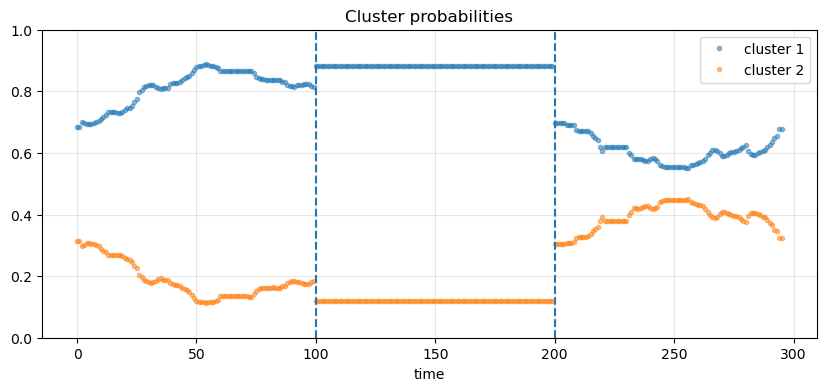

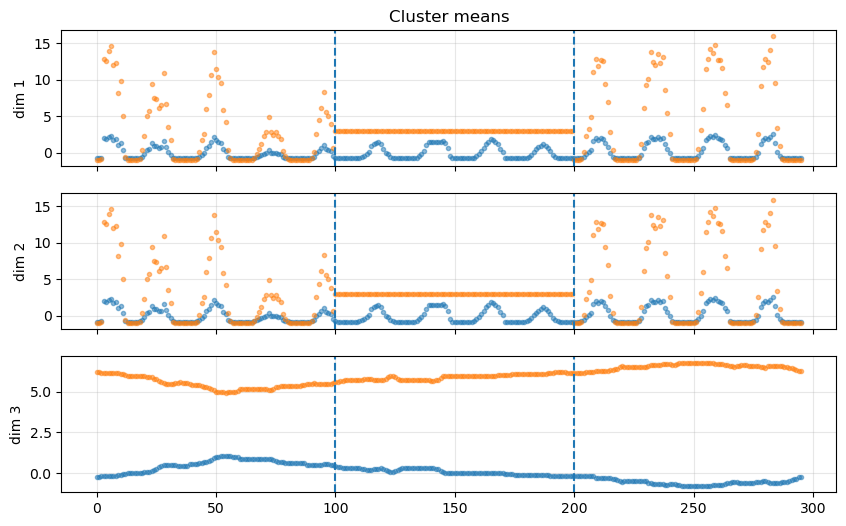

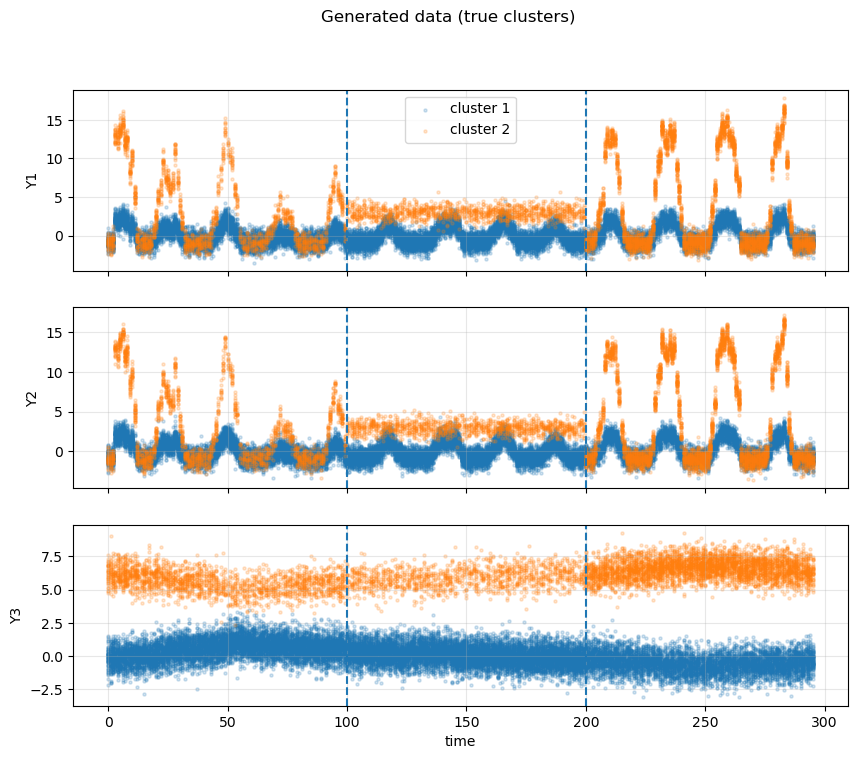

In [2]:
import pyreadr
import numpy as np

# load R covariates
X_r = pyreadr.read_r("../real_data_sim/sim_x_ult_5_1.RDS")
Xa = np.array(list(X_r.values())[0])

print("Xa shape:", Xa.shape)
X, Y, labels, pimat, mn_array = generate_real_covariate_mixture(
    Xa,
    n_samples=100,
    sigma=0.5,
    seed=1
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(pimat[:,0], '.', alpha=0.5, label='cluster 1')
plt.plot(pimat[:,1], '.', alpha=0.5, label='cluster 2')

plt.axvline(100, linestyle='--')
plt.axvline(200, linestyle='--')

plt.ylim(0,1)
plt.title("Cluster probabilities")
plt.xlabel("time")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(3,1, figsize=(10,6), sharex=True)

for d in range(3):
    axes[d].plot(mn_array[:,d,0], '.', alpha=0.5)
    axes[d].plot(mn_array[:,d,1], '.', alpha=0.5)

    axes[d].axvline(100, linestyle='--')
    axes[d].axvline(200, linestyle='--')

    axes[d].set_ylabel(f"dim {d+1}")
    axes[d].grid(alpha=0.3)

axes[0].set_title("Cluster means")
plt.show()


fig, axes = plt.subplots(3,1, figsize=(10,8), sharex=True)

colors = ['tab:blue', 'tab:orange']
T = Y.shape[0]

for d in range(3):
    for k in [0,1]:
        mask = (labels == k)

        t_vals = np.repeat(np.arange(T)[:,None], labels.shape[1], axis=1)

        axes[d].scatter(
            t_vals[mask],
            Y[:,:,d][mask],
            s=5,
            alpha=0.2,
            color=colors[k],
            label=f"cluster {k+1}" if d==0 else None
        )

    axes[d].axvline(100, linestyle='--')
    axes[d].axvline(200, linestyle='--')

    axes[d].set_ylabel(f"Y{d+1}")
    axes[d].grid(alpha=0.3)

axes[0].legend()
axes[-1].set_xlabel("time")

plt.suptitle("Generated data (true clusters)")
plt.show()


In [ ]:
import torch, random, io, sys, warnings
import os, numpy as np, pandas as pd, pyreadr
from tqdm import tqdm

import sys, os
sys.path.append(os.path.abspath(".."))

from cpd_model import parse_args, learn_one_seq_penalty

warnings.filterwarnings("ignore")

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# ======================================================
# CONFIG
# ======================================================
REPS = 10
TRUE_CP = [100, 200]

SIGMA_LIST = np.linspace(0.3, 0.8, 5)
TOL = 10

# ======================================================
# LOAD REAL COVARIATES
# ======================================================
X_r = pyreadr.read_r("../real_data_sim/sim_x_ult_5_1.RDS")
Xa = np.array(list(X_r.values())[0])

# ======================================================
# BASE ARGS
# ======================================================
base_args = parse_args()
base_args.epoch = 150
base_args.K_dim = 2
base_args.z_dim = 3
base_args.decoder_lr = 0.01
base_args.decoder_iteration = 20
base_args.langevin_s = 0.2
base_args.langevin_K = 100
base_args.kappa = 0.8
base_args.penalties = [0.01, 0.05, 0.1, 1]
base_args.nu_iteration = 20
base_args.output_layer = [50, 50]
base_args.scale_delta = False
base_args.signif_level = 0.99
base_args.true_CP_full = TRUE_CP

# ======================================================
# MAIN LOOP
# ======================================================
records = []

GLOBAL_SEED = 1

for sigma in SIGMA_LIST:

    print(f"\n==============================")
    print(f" Running sigma = {sigma:.3f}")
    print(f"==============================")

    for rep in range(1, REPS + 1):

        print(f"\n--- Replicate {rep}/{REPS} ---")

        SEED = GLOBAL_SEED + rep
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        # ============================
        # Generate data (Python version)
        # ============================
        X, Y, labels, pimat, mn_array = generate_real_covariate_mixture(
            Xa,
            n_samples=100,
            sigma=sigma,
            seed=SEED
        )

        # ============================
        # args
        # ============================
        args = parse_args()
        args.__dict__.update(base_args.__dict__)

        args.x_dim = X.shape[2]
        args.y_dim = Y.shape[2]
        args.num_time = X.shape[0]
        args.num_samples = X.shape[1]

        # ============================
        # tensor
        # ============================
        x_input = torch.tensor(X, dtype=torch.float32).to(device)
        y_input = torch.tensor(Y, dtype=torch.float32).to(device)

        odd_idx = range(1, args.num_time, 2)
        even_idx = range(0, args.num_time, 2)

        x_train = x_input[odd_idx].reshape(-1, args.x_dim)
        x_test  = x_input[even_idx].reshape(-1, args.x_dim)
        y_train = y_input[odd_idx].reshape(-1, args.y_dim)
        y_test  = y_input[even_idx].reshape(-1, args.y_dim)

        # ============================
        # penalty selection
        # ============================
        results_half = []

        for penalty in args.penalties:
            _stdout = sys.stdout
            # sys.stdout = io.StringIO()
            try:
                loss, pen = learn_one_seq_penalty(
                    args, x_train, y_train, x_test, y_test,
                    penalty=penalty, half=True
                )
            finally:
                sys.stdout = _stdout

            results_half.append([loss, pen])

        results_half = np.array(results_half)
        best_idx = np.argmin(results_half[:, 0])
        best_penalty = args.penalties[best_idx]

        print(f"[INFO] Best penalty = {best_penalty}")

        # ============================
        # full training
        # ============================
        _stdout = sys.stdout
        # sys.stdout = io.StringIO()
        try:
            out = learn_one_seq_penalty(
                args,
                x_input.reshape(-1, args.x_dim),
                y_input.reshape(-1, args.y_dim),
                x_input.reshape(-1, args.x_dim),
                y_input.reshape(-1, args.y_dim),
                penalty=best_penalty,
                half=False
            )
            result = out[0]
        finally:
            sys.stdout = _stdout

        torch.cuda.empty_cache()

        # ============================
        # evaluation
        # ============================
        est_cp = np.array(result[5], dtype=int) if len(result[5]) > 0 else np.array([])
        true_cp = np.array(TRUE_CP)

        if len(est_cp) == 0:
            cover_rate = 0
            avg_dist = np.nan
            FP = 0
            FN = len(true_cp)
        else:
            dist_mat = np.abs(est_cp[:, None] - true_cp[None, :])
            min_dist_true = dist_mat.min(axis=0)
            min_dist_est  = dist_mat.min(axis=1)

            cover_rate = np.mean(min_dist_true <= TOL)
            avg_dist   = np.mean(min_dist_true)
            FP = np.sum(min_dist_est > TOL)
            FN = np.sum(min_dist_true > TOL)

        # ============================
        # record
        # ============================
        records.append({
            "sigma": sigma,
            "rep": rep,
            "best_penalty": best_penalty,
            "num_detected": len(est_cp),

            # core output
            "est_CP": str(list(est_cp)),
            "true_CP": str(TRUE_CP),

            # optional
            "CE": result[0],
        })

# ======================================================
# SAVE
# ======================================================
df = pd.DataFrame(records)
df.to_csv("cpd_sigma_experiment.csv", index=False)

[INFO] Using device: cuda

 Running sigma = 0.300

--- Replicate 1/10 ---
Epoch   5 | Loss=513.934814 | Kurtosis=4.942401
Epoch  10 | Loss=471.803619 | Kurtosis=10.456239
Epoch  15 | Loss=444.143829 | Kurtosis=4.913496
Epoch  20 | Loss=434.562286 | Kurtosis=4.544219
Epoch  25 | Loss=429.973511 | Kurtosis=5.336815
Epoch  30 | Loss=427.870728 | Kurtosis=6.248233
Epoch  35 | Loss=427.792023 | Kurtosis=6.206981
Epoch  40 | Loss=427.238159 | Kurtosis=6.582042
Epoch  45 | Loss=427.729004 | Kurtosis=6.411651
Epoch  50 | Loss=424.565613 | Kurtosis=5.674376
Epoch  55 | Loss=425.689667 | Kurtosis=5.850988
Epoch  60 | Loss=425.460541 | Kurtosis=6.248816
Epoch  65 | Loss=425.498352 | Kurtosis=6.819851
Epoch  70 | Loss=426.139221 | Kurtosis=6.423010
Epoch  75 | Loss=426.099945 | Kurtosis=7.501841
Epoch  80 | Loss=425.885620 | Kurtosis=6.650524
Epoch  85 | Loss=425.746674 | Kurtosis=6.861976
Epoch  90 | Loss=426.088196 | Kurtosis=7.082546
Epoch  95 | Loss=426.676880 | Kurtosis=6.478443
Epoch 100 | L